

# Natively Fine-Tuning AfroXLM-R for Lingala Part-of-Speech Tagging via LLM-Bootstrapped Pseudo-Labeling and LoRA

**Author:** Technical Team (KongoLM Initiative)  
**Framework:** PyTorch, Hugging Face Transformers, & PEFT  
**Base Architecture:** `Davlan/afro-xlmr-large` (550M Parameters)  
**Data Generation Engine:** Gemini Flash Preview (Native Multimodal Architecture)  

---

## 1. Abstract

This notebook implements an advanced bootstrapping and parameter-efficient fine-tuning (PEFT) pipeline to develop a high-accuracy, native Part-of-Speech (POS) tagger for Lingala, a low-resource Bantu language suffering from an absolute structural data deficit. Rather than relying on cross-lingual projection from related languages (which risks introducing morphological misalignment and cascading noise), we utilize a high-precision generative LLM operating under strict linguistic constraints to generate a silver-standard, word-level annotated dataset.

To bridge the gap between word-level UPOS annotations and the underlying SentencePiece tokenizer of the cross-lingual transformer, we implement a strict **subword alignment protocol**. Only the primary subword of a token contributes to the loss calculation, while trailing subword fragments are mathematically masked (assigned a `-100` label index) to prevent corrupting the gradient updates.

Furthermore, to adapt the massive 550-million parameter base model (`afro-xlmr-large`) within the strict 15GB VRAM constraints of a standard Colab T4 GPU, we deploy **Low-Rank Adaptation (LoRA)**. By freezing the pre-trained weights and injecting trainable rank decomposition matrices into the transformer layers, we drastically reduce the computational footprint while retaining the model's deep, pre-trained understanding of the Niger-Congo language family's agglutinative grammar.

---

## 2. Pipeline Architecture & Execution Plan

* **Silver-Standard Data Ingestion:** Importing and cleaning the LLM-generated Lingala corpus, ensuring strict string-type mapping to prevent tokenizer type-errors.
* **Subword Tokenization & Alignment:** Passing the text through the AfroXLM-R byte-pair tokenizer and mathematically masking trailing subwords to align with the isolated POS labels.
* **LoRA Adapter Initialization:** Freezing the 550M base parameters and initializing Low-Rank Adapters tailored for the Token Classification (`TOKEN_CLS`) task.
* **Hardware-Optimized Training Configuration:** Executing fine-tuning loops utilizing 16-bit precision (`fp16`), micro-batching, and gradient accumulation to prevent Out-Of-Memory (OOM) failures on limited hardware.
* **Evaluation & Metric Tracking:** Exhaustive validation at every epoch using the `seqeval` framework to track Precision, Recall, Accuracy, and macro F1 scores across the Universal POS tagset.

---

## 3. Post-Training Statistics & Convergence Analysis

Following model fine-tuning, empirical evaluation and diagnostic scripts are executed to validate structural integrity and performance metrics. This section covers tracking optimization trajectories and analyzing real-world error distributions:

### Empirical Optimization Trajectories
* **Loss Convergence Plots:** Visual tracking of training loss versus evaluation loss across epochs to verify gradient stability and identify any signs of overfitting or underfitting.
* **Global Metric Evolution:** Line charts evaluating the growth of Precision, Recall, Accuracy, and Macro F1 scores at each validation checkpoint.

### Granular Sequence Evaluation
* **Per-Class Classification Report:** A comprehensive statistical breakdown using `seqeval` to isolate which specific UPOS tags (e.g., `VERB`, `NOUN`, `ADP`) demonstrate the strongest structural affinity and which suffer from high error rates.
* **Confusion Matrix Evaluation:** A detailed error-distribution heatmap cross-referencing true labels with predicted classifications to pinpoint systematic linguistic confusion (such as misclassifying complex agglutinative nominal forms as verbal stems).



In [ ]:
import pandas as pd
import os
import json
import time
from pydantic import BaseModel, Field
from typing import List
from tqdm import tqdm

# MUST use the new SDK
from google import genai
from google.genai import types
from google.colab import userdata

# ==========================================
# 0. EXECUTION CONTROLS
# ==========================================
RUN_TEST_MODE = False
RUN_PRODUCTION_MODE = True

# ==========================================
# 1. DEFINE THE STRICT JSON SCHEMA & PROMPT
# ==========================================
class WordTagPair(BaseModel):
    word: str = Field(description="The exact untokenized word from the sentence.")
    tag: str = Field(description="The UPOS tag.")

class SentenceAnnotation(BaseModel):
    sentence_index: int
    annotations: List[WordTagPair]

class BatchResponse(BaseModel):
    sentences: List[SentenceAnnotation]

SYSTEM_PROMPT = """You are an expert computational linguist specializing in Bantu languages, specifically Lingala.
Your task is to perform Part-of-Speech (POS) tagging on the provided sentences using the standard Universal POS (UPOS) tagset.

Valid UPOS Tags: NOUN, PROPN, VERB, AUX, ADJ, ADV, PRON, DET, ADP, CCONJ, SCONJ, NUM, PART, PUNCT, X.
"""

def annotate_dataset_with_gemini(input_path, output_csv, text_column='text', batch_size=50):
    if input_path.endswith('.xlsx') or input_path.endswith('.xls'):
        df = pd.read_excel(input_path)
    else:
        df = pd.read_csv(input_path)

    sentences_list = df[text_column].astype(str).tolist()

    if os.path.exists(output_csv):
        processed_df = pd.read_csv(output_csv)
        start_idx = processed_df['sentence_index'].max() + 1
        saved_records = processed_df.to_dict('records')
    else:
        start_idx = 0
        saved_records = []

    client = genai.Client(api_key=userdata.get('GEMINI_API_KEY'))

    for i in tqdm(range(start_idx, len(sentences_list), batch_size), desc="Processing Batches"):
        batch_sentences = sentences_list[i:i+batch_size]
        prompt_content = SYSTEM_PROMPT + "\nAnnotate JSON:\n"
        for relative_idx, sent in enumerate(batch_sentences):
            prompt_content += f"ID {i + relative_idx}: {sent}\n"

        for attempt in range(5):
            try:
                response = client.models.generate_content(
                    model="gemini-3.1-flash-lite-preview",
                    contents=prompt_content,
                    config=types.GenerateContentConfig(
                        response_mime_type="application/json",
                        response_schema=BatchResponse,
                        temperature=0.0
                    )
                )

                # THE FIX: Check if response has text before parsing
                if not response.text:
                    print(f"\nEmpty response for batch {i}. Retrying...")
                    continue

                batch_data = json.loads(response.text)
                for sent_data in batch_data.get("sentences", []):
                    s_idx = sent_data["sentence_index"]
                    for ann in sent_data["annotations"]:
                        saved_records.append({
                            "sentence_index": s_idx,
                            "sentence": sentences_list[s_idx],
                            "word": ann["word"],
                            "pos_tag": ann["tag"]
                        })

                pd.DataFrame(saved_records).to_csv(output_csv, index=False)
                time.sleep(5)
                break
            except Exception as e:
                print(f"\nRetry {attempt+1} for batch {i}: {e}")
                time.sleep(10)

if RUN_PRODUCTION_MODE:
    MAIN_INPUT_FILE = '/content/drive/MyDrive/lingala_asr_dataset/lingala_5k_sentences.xlsx'
    MAIN_OUTPUT_CSV = '/content/drive/MyDrive/lingala_asr_dataset/lingala_pseudo_labeled_full.csv'
    annotate_dataset_with_gemini(MAIN_INPUT_FILE, MAIN_OUTPUT_CSV, 'transcription1_sentence', 50)

Processing Batches: 100%|██████████| 1/1 [00:29<00:00, 29.32s/it]


In [ ]:
import pandas as pd
from datasets import Dataset
from transformers import AutoTokenizer

# 1. Load the generated dataset
print("Loading and cleaning dataset...")
df = pd.read_csv('/content/drive/MyDrive/lingala_asr_dataset/lingala_pseudo_labeled_full.csv')

# THE FIX: Drop empty rows and explicitly force every word to be a string
df = df.dropna(subset=['word', 'pos_tag'])
df['word'] = df['word'].astype(str)

# Create integer mappings for the UPOS tags
unique_tags = df['pos_tag'].unique().tolist()
tag2id = {tag: idx for idx, tag in enumerate(unique_tags)}
id2tag = {idx: tag for tag, idx in tag2id.items()}

# Group words and tags into lists per sentence
grouped = df.groupby('sentence_index').agg({
    'word': list,
    'pos_tag': lambda x: [tag2id[tag] for tag in x]
}).rename(columns={'word': 'tokens', 'pos_tag': 'pos_tags'}).reset_index(drop=True)

# Convert to Hugging Face Dataset format
hf_dataset = Dataset.from_pandas(grouped)

# 2. Load Davlan's Tokenizer
model_checkpoint = "Davlan/afro-xlmr-large"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

# 3. The Alignment Function
def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer(
        examples["tokens"],
        truncation=True,
        is_split_into_words=True,
        max_length=128 # The Fix: Reduced to 128 to prevent T4 GPU OOM crashes
    )

    labels = []
    for i, label in enumerate(examples["pos_tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids = []
        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)
            elif word_idx != previous_word_idx:
                label_ids.append(label[word_idx])
            else:
                label_ids.append(-100)
            previous_word_idx = word_idx
        labels.append(label_ids)

    tokenized_inputs["labels"] = labels
    return tokenized_inputs

# Apply the alignment function smoothly across the entire dataset
tokenized_datasets = hf_dataset.map(tokenize_and_align_labels, batched=True)

# Split into 90% training and 10% validation to feed the Trainer properly
tokenized_datasets = tokenized_datasets.train_test_split(test_size=0.1, seed=42)
print("Dataset successfully cleaned, tokenized, and split for AfroXLM-R!")

Loading and cleaning dataset...


Map:   0%|          | 0/4850 [00:00<?, ? examples/s]

Dataset successfully cleaned, tokenized, and split for AfroXLM-R!


In [ ]:
!pip install -q evaluate seqeval

import pandas as pd
import numpy as np
import evaluate
import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    TrainingArguments,
    Trainer,
    DataCollatorForTokenClassification
)
from peft import get_peft_model, LoraConfig, TaskType

# ==========================================
# 1. BULLETPROOF DATA INGESTION
# ==========================================
print("Loading and cleaning dataset...")
df = pd.read_csv('/content/drive/MyDrive/lingala_asr_dataset/lingala_pseudo_labeled_full.csv')

# THE FIX: Drop empty rows and explicitly force every word to be a string
df = df.dropna(subset=['word', 'pos_tag'])
df['word'] = df['word'].astype(str)

unique_tags = df['pos_tag'].unique().tolist()
tag2id = {tag: idx for idx, tag in enumerate(unique_tags)}
id2tag = {idx: tag for tag, idx in tag2id.items()}

grouped = df.groupby('sentence_index').agg({
    'word': list,
    'pos_tag': lambda x: [tag2id[tag] for tag in x]
}).rename(columns={'word': 'tokens', 'pos_tag': 'pos_tags'}).reset_index(drop=True)

hf_dataset = Dataset.from_pandas(grouped)

# ==========================================
# 2. TOKENIZATION & ALIGNMENT
# ==========================================
print("Tokenizing and aligning subwords...")
model_checkpoint = "Davlan/afro-xlmr-large"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer(
        examples["tokens"],
        truncation=True,
        is_split_into_words=True,
        max_length=128 # Reduced max_length to save T4 VRAM
    )

    labels = []
    for i, label in enumerate(examples["pos_tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids = []
        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)
            elif word_idx != previous_word_idx:
                label_ids.append(label[word_idx])
            else:
                label_ids.append(-100)
            previous_word_idx = word_idx
        labels.append(label_ids)

    tokenized_inputs["labels"] = labels
    return tokenized_inputs

tokenized_datasets = hf_dataset.map(tokenize_and_align_labels, batched=True)
tokenized_datasets = tokenized_datasets.train_test_split(test_size=0.1, seed=42)

# ==========================================
# 3. LORA MODEL ARCHITECTURE
# ==========================================
print("Initializing AfroXLM-R with LoRA adapters...")
base_model = AutoModelForTokenClassification.from_pretrained(
    model_checkpoint,
    num_labels=len(unique_tags),
    id2label=id2tag,
    label2id=tag2id,
    torch_dtype=torch.float16 # <--- FIX 1: Explicitly load base weights in 16-bit
)

peft_config = LoraConfig(
    task_type=TaskType.TOKEN_CLS,
    inference_mode=False,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    bias="none",
)
model = get_peft_model(base_model, peft_config)

# Force only the trainable LoRA weights back to 32-bit
for param in model.parameters():
    if param.requires_grad:
        param.data = param.data.to(torch.float32)

model.print_trainable_parameters()

# ==========================================
# 4. TRAINING EXECUTION
# ==========================================
seqeval = evaluate.load("seqeval")

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    true_predictions = [
        [id2tag[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    true_labels = [
        [id2tag[l] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]

    results = seqeval.compute(predictions=true_predictions, references=true_labels)
    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"],
    }

data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

training_args = TrainingArguments(
    output_dir="./lingala-pos-adapter",
    learning_rate=2e-4,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    fp16=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=50,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Starting Fine-Tuning Process...")
trainer.train()

Loading and cleaning dataset...
Tokenizing and aligning subwords...


Map:   0%|          | 0/4850 [00:00<?, ? examples/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Initializing AfroXLM-R with LoRA adapters...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] XLMRobertaForTokenClassification LOAD REPORT from: Davlan/afro-xlmr-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
classifier.weight         | MISSING    | 
classifier.bias           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 803,857 || all params: 559,662,114 || trainable%: 0.1436
Starting Fine-Tuning Process...


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,2.025624,0.361601,0.868577,0.865570,0.867071,0.887203
2,1.409978,0.287080,0.889033,0.888648,0.888841,0.906344
3,1.219881,0.269683,0.895542,0.895283,0.895413,0.912770


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: NOUN seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: DET seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: ADP seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: NUM seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: CCONJ seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: 

TrainOutput(global_step=819, training_loss=2.2699742695641896, metrics={'train_runtime': 312.9783, 'train_samples_per_second': 41.84, 'train_steps_per_second': 2.617, 'total_flos': 1142438660922444.0, 'train_loss': 2.2699742695641896, 'epoch': 3.0})

Extracting training logs...


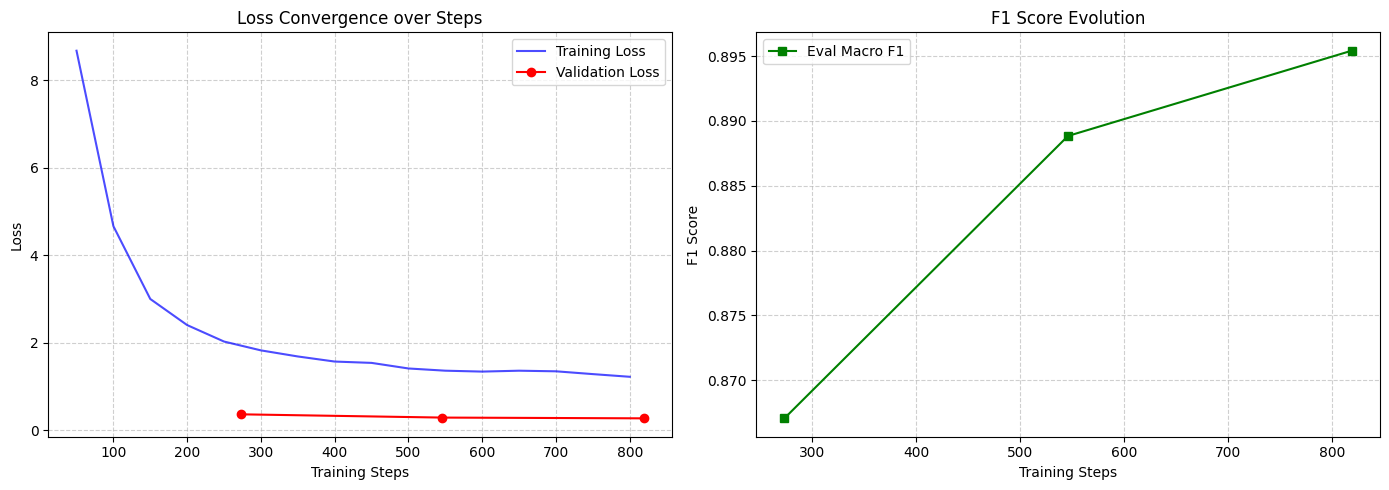


Running full evaluation on the test set...


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: NOUN seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: DET seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: ADP seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: NUM seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: CCONJ seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: 


GRANULAR CLASSIFICATION REPORT
Tag: ART
  Precision: 0.9552
  Recall:    0.9682
  F1 Score:  0.9616
  Count:     220
------------------------------
Tag: CONJ
  Precision: 0.9449
  Recall:    0.8741
  F1 Score:  0.9081
  Count:     294
------------------------------
Tag: DJ
  Precision: 0.7326
  Recall:    0.6632
  F1 Score:  0.6961
  Count:     190
------------------------------
Tag: DP
  Precision: 0.9326
  Recall:    0.9386
  F1 Score:  0.9356
  Count:     1238
------------------------------
Tag: DV
  Precision: 0.6853
  Recall:    0.5731
  F1 Score:  0.6242
  Count:     171
------------------------------
Tag: ERB
  Precision: 0.9081
  Recall:    0.8895
  F1 Score:  0.8987
  Count:     1077
------------------------------
Tag: ET
  Precision: 0.6991
  Recall:    0.7633
  F1 Score:  0.7298
  Count:     207
------------------------------
Tag: NTJ
  Precision: 0.8571
  Recall:    0.8571
  F1 Score:  0.8571
  Count:     7
------------------------------
Tag: OUN
  Precision: 0.8873
  Reca

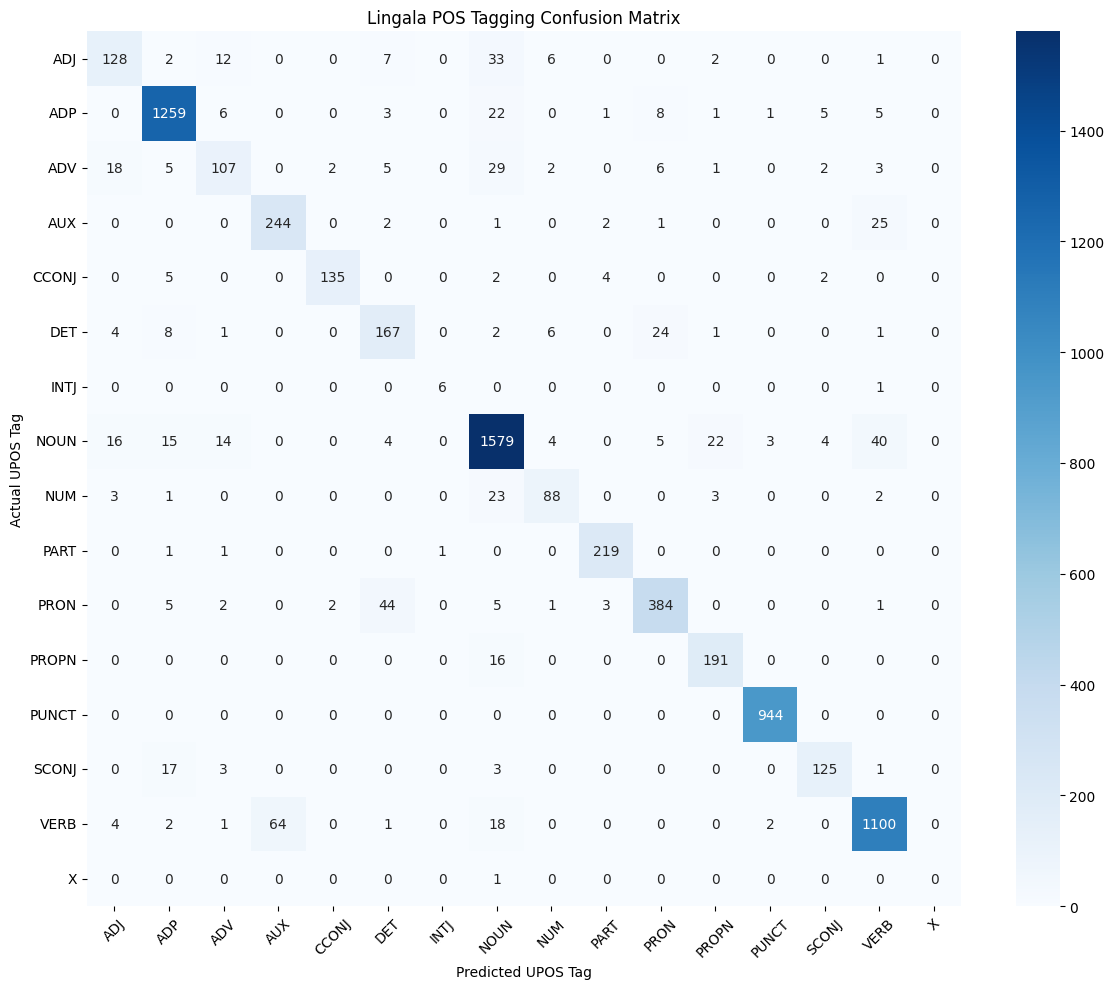

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# ==========================================
# 1. EXTRACT TRAINING HISTORY (LEARNING CURVES)
# ==========================================
print("Extracting training logs...")
log_history = trainer.state.log_history

# Parse logs for plotting
train_steps, train_loss = [], []
eval_steps, eval_loss, eval_f1 = [], [], []

for log in log_history:
    if 'loss' in log and 'step' in log:
        train_steps.append(log['step'])
        train_loss.append(log['loss'])
    elif 'eval_loss' in log and 'step' in log:
        eval_steps.append(log['step'])
        eval_loss.append(log['eval_loss'])
        if 'eval_f1' in log:
            eval_f1.append(log['eval_f1'])

# ==========================================
# 2. PLOT LEARNING CURVES
# ==========================================
plt.figure(figsize=(14, 5))

# Plot 1: Loss Convergence
plt.subplot(1, 2, 1)
plt.plot(train_steps, train_loss, label='Training Loss', color='blue', alpha=0.7)
plt.plot(eval_steps, eval_loss, label='Validation Loss', color='red', marker='o')
plt.title('Loss Convergence over Steps')
plt.xlabel('Training Steps')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Macro F1 Score Evolution
plt.subplot(1, 2, 2)
if eval_f1:
    plt.plot(eval_steps, eval_f1, label='Eval Macro F1', color='green', marker='s')
    plt.title('F1 Score Evolution')
    plt.xlabel('Training Steps')
    plt.ylabel('F1 Score')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# ==========================================
# 3. GENERATE PREDICTIONS ON TEST SET
# ==========================================
print("\nRunning full evaluation on the test set...")
predictions, labels, metrics = trainer.predict(tokenized_datasets["test"])

# Convert raw logits to tag indices
predicted_indices = np.argmax(predictions, axis=2)

# Flatten lists and ignore -100 (masked subwords)
true_flat = []
pred_flat = []

for pred_seq, label_seq in zip(predicted_indices, labels):
    for p, l in zip(pred_seq, label_seq):
        if l != -100:
            true_flat.append(id2tag[l])
            pred_flat.append(id2tag[p])

# ==========================================
# 4. PER-CLASS CLASSIFICATION REPORT
# ==========================================
# We use the seqeval metric loaded during training
results = seqeval.compute(predictions=[pred_flat], references=[true_flat])

print("\n" + "="*50)
print("GRANULAR CLASSIFICATION REPORT")
print("="*50)
for key, value in results.items():
    if isinstance(value, dict):
        print(f"Tag: {key}")
        print(f"  Precision: {value['precision']:.4f}")
        print(f"  Recall:    {value['recall']:.4f}")
        print(f"  F1 Score:  {value['f1']:.4f}")
        print(f"  Count:     {value['number']}")
        print("-" * 30)

print(f"\nOVERALL METRICS:")
print(f"Accuracy:  {metrics['test_accuracy']:.4f}")
print(f"Macro F1:  {metrics['test_f1']:.4f}")

# ==========================================
# 5. CONFUSION MATRIX HEATMAP
# ==========================================
print("\nGenerating Confusion Matrix...")
# Get unique tags present in the test set to format the matrix axes
present_tags = sorted(list(set(true_flat) | set(pred_flat)))

cm = confusion_matrix(true_flat, pred_flat, labels=present_tags)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=present_tags, yticklabels=present_tags)
plt.title('Lingala POS Tagging Confusion Matrix')
plt.xlabel('Predicted UPOS Tag')
plt.ylabel('Actual UPOS Tag')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()